In [161]:
# Import the system functions and download the data from the Think stats URL

from os.path import basename, exists

# This function is used to download all the required files used for NSFG

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkstats2.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkplot.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/first.py")


download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/2002FemPreg.dct")
download(
    "https://github.com/AllenDowney/ThinkStats2/raw/master/code/2002FemPreg.dat.gz"
)

In [163]:
#import all the required functions need to be used for this excercise

import numpy as np
import nsfg
import first
import thinkstats2
import thinkplot

In [165]:
#**Exercise:** 3.1 && 3.2 

In [167]:
# getting mean value using PMF
pmf.Mean()

0.507339536140008

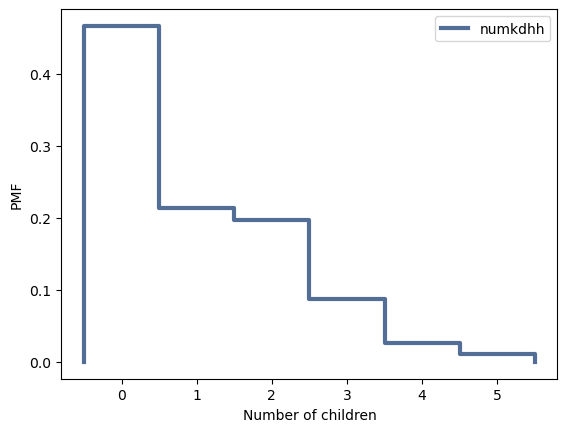

In [169]:
resp = nsfg.ReadFemResp()
pmf = thinkstats2.Pmf(resp.numkdhh, label="numkdhh")

thinkplot.Pmf(pmf)
thinkplot.Config(xlabel="Number of children", ylabel="PMF")

In [170]:
# This function is used to get the biased distributions for NSFG

def BiasPmf(pmf, label):
    new_pmf = pmf.Copy(label=label)

    for x, p in pmf.Items():
        new_pmf.Mult(x, x)

    new_pmf.Normalize()
    return new_pmf

In [171]:
biased = BiasPmf(pmf, label="biased")


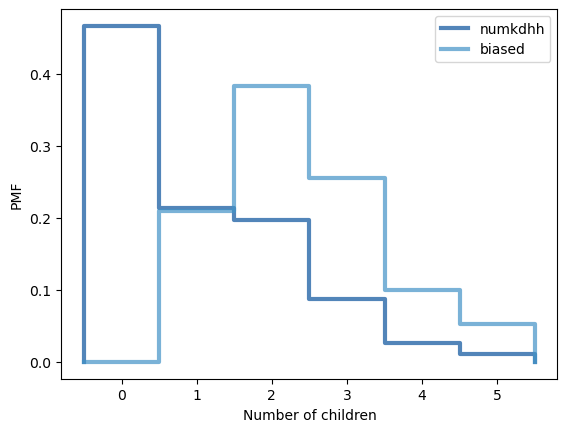

In [172]:
# Get graphical representation of numkdhh vs biased

thinkplot.PrePlot(2)
thinkplot.Pmfs([pmf, biased])
thinkplot.Config(xlabel="Number of children", ylabel="PMF")

In [173]:
biased.Mean()

2.403679100664282

In [174]:
#Excercise 4.1 && 4.2

In [175]:
#`PercentileRank` computes the fraction of `scores` less than or equal to `your_score`.

def PercentileRank(scores, your_score):
    count = 0
    for score in scores:
        if score <= your_score:
            count += 1

    percentile_rank = 100.0 * count / len(scores)
    return percentile_rank

In [176]:
def Percentile(scores, percentile_rank):
    scores.sort()
    for score in scores:
        if PercentileRank(scores, score) >= percentile_rank:
            return score

In [246]:
# function to evaluate CDF

def EvalCdf(sample, x):
    count = 0.0
    for value in sample:
        if value <= x:
            count += 1

    prob = count / len(sample)
    return prob

In [252]:
import first

live, firsts

(       caseid  pregordr  howpreg_n  howpreg_p  moscurrp  nowprgdk  pregend1  \
 0           1         1        NaN        NaN       NaN       NaN       6.0   
 1           1         2        NaN        NaN       NaN       NaN       6.0   
 2           2         1        NaN        NaN       NaN       NaN       5.0   
 3           2         2        NaN        NaN       NaN       NaN       6.0   
 4           2         3        NaN        NaN       NaN       NaN       6.0   
 ...       ...       ...        ...        ...       ...       ...       ...   
 13581   12568         2        NaN        NaN       NaN       NaN       5.0   
 13584   12569         2        NaN        NaN       NaN       NaN       6.0   
 13588   12571         1        NaN        NaN       NaN       NaN       6.0   
 13591   12571         4        NaN        NaN       NaN       NaN       6.0   
 13592   12571         5        NaN        NaN       NaN       NaN       6.0   
 
        pregend2  nbrnaliv  multbrth  

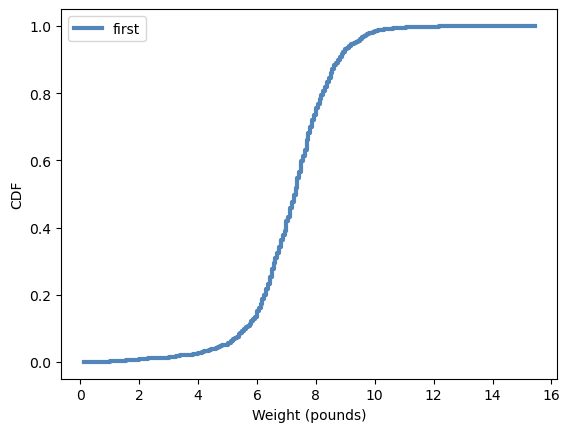

In [254]:
first_cdf = thinkstats2.Cdf(firsts.totalwgt_lb, label='first')

thinkplot.PrePlot(2)
thinkplot.Cdfs([first_cdf])
thinkplot.Config(xlabel='Weight (pounds)', ylabel='CDF')

In [256]:
first_cdf.PercentileRank(8.5)

85.90419436167774

In [258]:
other_cdf.PercentileRank(8.5)

82.35294117647058

In [260]:
t = np.random.random(1000)

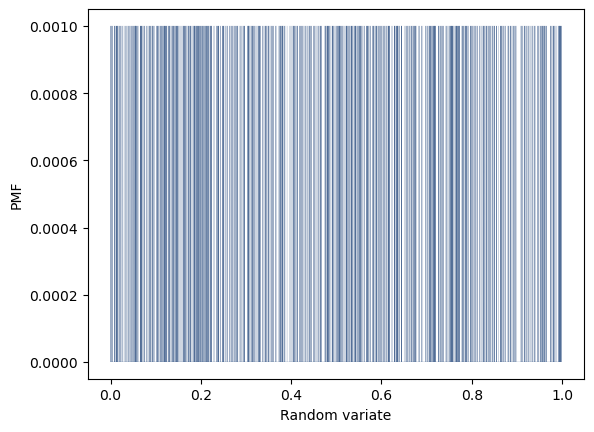

In [262]:
pmf = thinkstats2.Pmf(t)
thinkplot.Pmf(pmf, linewidth=0.1)
thinkplot.Config(xlabel='Random variate', ylabel='PMF')

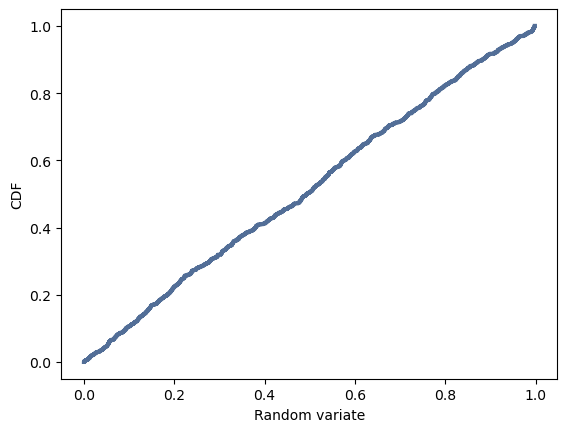

In [264]:
cdf = thinkstats2.Cdf(t)
thinkplot.Cdf(cdf)
thinkplot.Config(xlabel='Random variate', ylabel='CDF')